In [ ]:
# ACC102 Track 2 Project
# Microsoft vs Apple Stock Performance Analysis (2023)
# Name: Zhou Tengli
# Student ID: 2471793

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
db = wrds.Connection()

Enter your WRDS username [27414]:zhoutengli
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
pgpass file created at C:\Users\27414\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
query = """
    SELECT permno, date, prc
    FROM crsp.dsf
    WHERE (permno = 10107 OR permno = 14593)
    AND date >= '2023-01-01' AND date <= '2023-12-31'
"""
df = db.raw_sql(query)

In [4]:
df['date'] = pd.to_datetime(df['date'])
df['prc'] = df['prc'].abs()
df = df.dropna()

In [6]:
# Separate data for two stocks
msft = df[df['permno'] == 10107].copy().set_index('date')
aapl = df[df['permno'] == 14593].copy().set_index('date')

In [7]:
# Calculate daily returns
msft['return'] = msft['prc'].pct_change()
aapl['return'] = aapl['prc'].pct_change()

In [8]:
# Calculate annualized volatility
msft_volatility = msft['return'].std() * np.sqrt(252)
aapl_volatility = aapl['return'].std() * np.sqrt(252)

In [9]:
# Calculate cumulative returns
msft['cumulative_return'] = (1 + msft['return']).cumprod()
aapl['cumulative_return'] = (1 + aapl['return']).cumprod()

In [14]:
msft['30d_ma'] = msft['prc'].rolling(window=30).mean()
aapl['30d_ma'] = aapl['prc'].rolling(window=30).mean()

In [17]:
# Calculate correlation
correlation = msft['prc'].corr(aapl['prc'])

In [18]:
# Display key results
print("=== Project Results ===")
print(f"Microsoft Annualized Volatility: {msft_volatility:.2%}")
print(f"Apple Annualized Volatility: {aapl_volatility:.2%}")
print(f"Correlation between two stocks: {correlation:.4f}")

=== Project Results ===
Microsoft Annualized Volatility: 25.13%
Apple Annualized Volatility: 19.95%
Correlation between two stocks: 0.9478


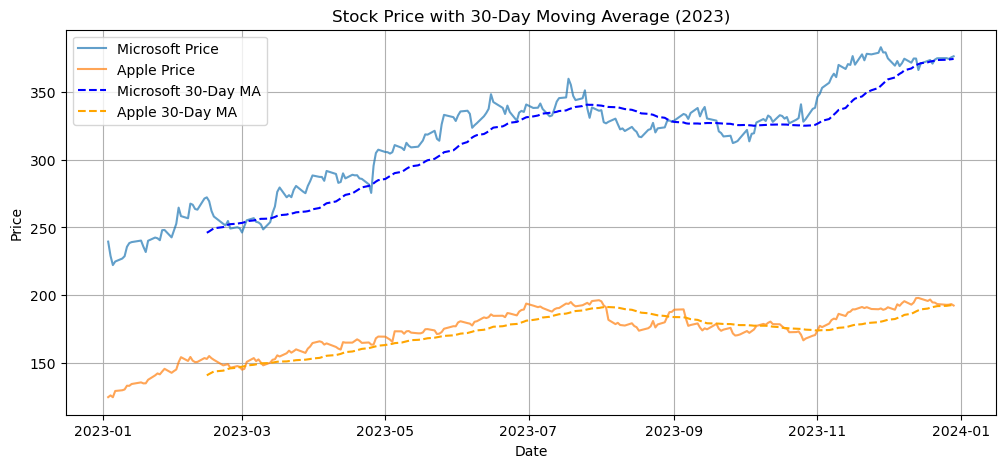

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(msft['prc'], label='Microsoft Price', alpha=0.7)
plt.plot(aapl['prc'], label='Apple Price', alpha=0.7)
plt.plot(msft['30d_ma'], label='Microsoft 30-Day MA', linestyle='--', color='blue')
plt.plot(aapl['30d_ma'], label='Apple 30-Day MA', linestyle='--', color='orange')
plt.title('Stock Price with 30-Day Moving Average (2023)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

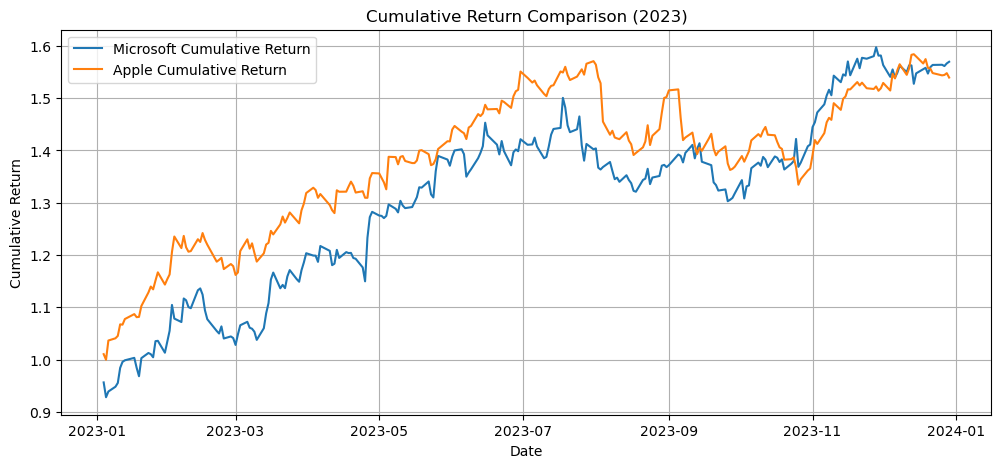

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(msft['cumulative_return'], label='Microsoft Cumulative Return')
plt.plot(aapl['cumulative_return'], label='Apple Cumulative Return')
plt.title('Cumulative Return Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()